# Portfolio Concentration Analysis
*Module C · Notebook 3 of 3 · AI Risk Decisioning System*

---

## Business Context

A bank that approves each loan purely on individual borrower merit — ignoring what that
loan does to the portfolio — is not practising modern credit risk management.

**Concentration risk** is the danger that too many loans in the same category default
simultaneously because they share the same underlying macro driver. A book that is
80% debt consolidation is exposed to a job-loss recession in a way that a diversified
book is not. A book that is 60% 60-month loans maturing in the same year has
refinancing and liquidity risk that a spread-term book avoids.

Module C's portfolio analysis answers: **does this proposed loan make the portfolio
better or worse on a concentration basis?**

### What This Module Produces

1. **Portfolio composition dashboard** — current mix by grade, purpose, term, FICO
2. **Concentration risk metrics** — Herfindahl-Hirschman Index (HHI) by segment
3. **Vintage analysis** — default rate trends over time (2007-2018)
4. **Approval/rejection rate analysis** — using the rejected loans dataset
5. **Concentration flag logic** — the binary signal fed to the Decision Engine

### How the Concentration Flag Works in the Decision Engine

The concentration flag is `True` when approving this loan would:
- Add to a purpose category already above 30% of the portfolio
- Add a 60-month loan when 60-month term exceeds 35% of the book
- Add to a geographic concentration above threshold

This transforms individual loan approval into portfolio-aware decisioning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import pickle

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../04_outputs", exist_ok=True)
print("Libraries loaded. Module C - Portfolio Concentration Analysis.")


Libraries loaded. Module C - Portfolio Concentration Analysis.


---
## 1. Load Data

In [2]:
df = pd.read_csv("../01_data/processed/clean_lendingclub.csv")
scored_c = pd.read_csv("../01_data/processed/scored_test_c.csv")
rej_summary = pd.read_csv("../01_data/processed/rejection_summary.csv")

print(f"Full cleaned dataset  : {df.shape[0]:,} rows | {df.shape[1]} cols")
print(f"Scored test set       : {scored_c.shape[0]:,} rows")
print(f"Rejection summary     : {rej_summary.shape[0]} purpose categories")
print(f"\nOverall default rate  : {df['DEFAULT'].mean():.4f} ({df['DEFAULT'].mean()*100:.2f}%)")

# Grade mapping for display
grade_letter_map = {1:'A',2:'B',3:'C',4:'D',5:'E',6:'F',7:'G'}
if "grade_n" in df.columns:
    df["grade"] = df["grade_n"].map(grade_letter_map)


Full cleaned dataset  : 299,877 rows | 33 cols
Scored test set       : 59,976 rows
Rejection summary     : 14 purpose categories

Overall default rate  : 0.2018 (20.18%)


---
## 2. Portfolio Composition Dashboard

Understanding the current portfolio composition is the baseline for concentration analysis.
We look at four dimensions: grade, purpose, term, and FICO band.

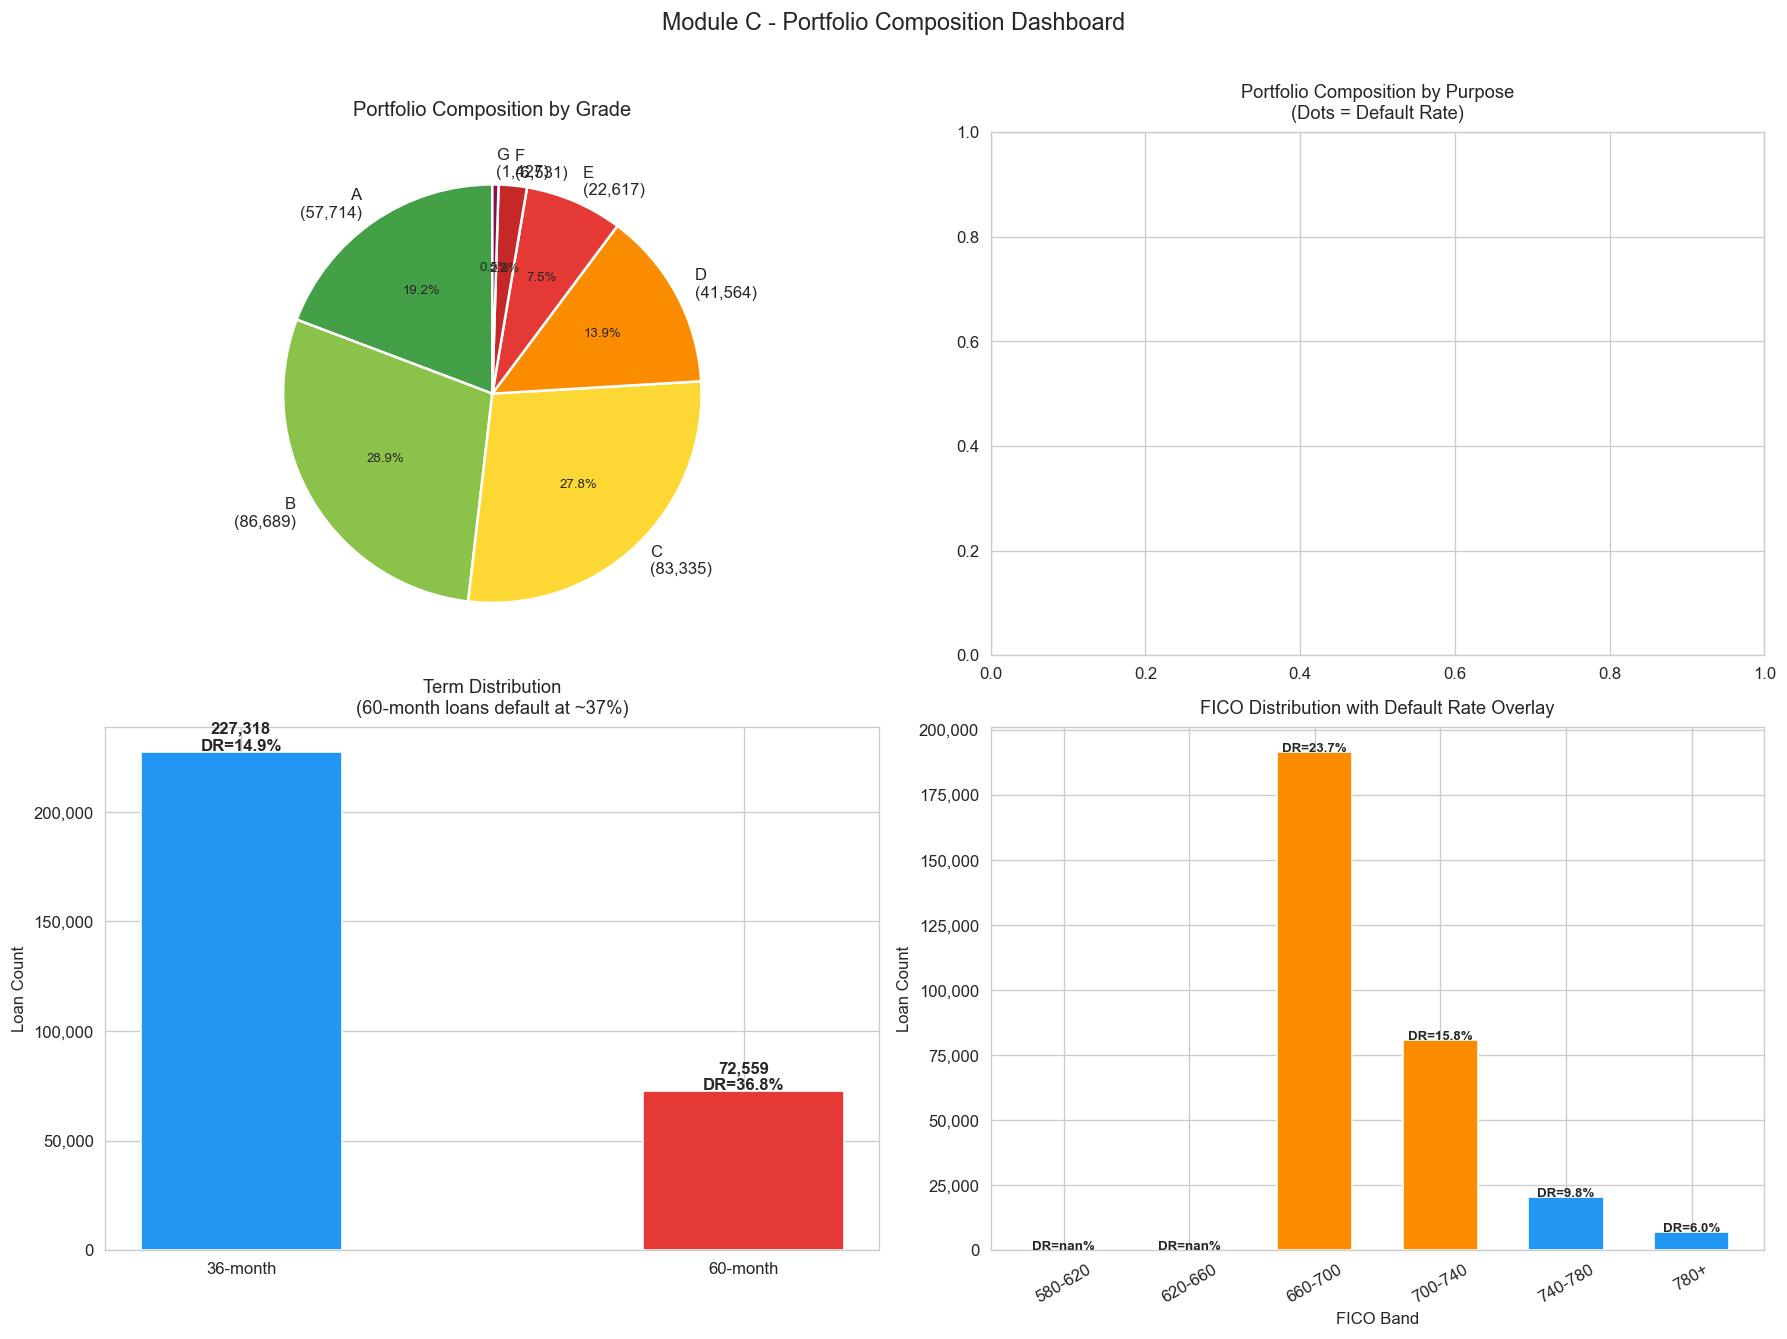

In [3]:
BLUE, RED = "#2196F3", "#E53935"
grade_order  = ["A","B","C","D","E","F","G"]
grade_colors = ["#43A047","#8BC34A","#FDD835","#FB8C00","#E53935","#C62828","#880E4F"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Grade distribution (pie + default rate bars combined)
ax = axes[0,0]
grade_counts = df["grade"].value_counts().reindex(grade_order, fill_value=0)
wedges, texts, autotexts = ax.pie(
    grade_counts.values,
    labels=[f"{g}\n({c:,})" for g,c in zip(grade_order, grade_counts.values)],
    colors=grade_colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":1.5}
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title("Portfolio Composition by Grade", fontsize=12, pad=10)

# 2. Purpose breakdown
ax = axes[0,1]
purpose_counts = df["purpose"].value_counts().head(10) if "purpose" in df.columns else pd.Series()
if len(purpose_counts) > 0:
    purpose_dr    = df.groupby("purpose")["DEFAULT"].mean().reindex(purpose_counts.index)
    bar_colors_p  = [RED if dr > 0.25 else "#FB8C00" if dr > 0.18 else BLUE
                     for dr in purpose_dr.values]
    bars = ax.barh(purpose_counts.index[::-1], purpose_counts.values[::-1],
                   color=bar_colors_p[::-1], edgecolor="white", height=0.6)
    ax2 = ax.twiny()
    ax2.plot(purpose_dr.values[::-1]*100,
             range(len(purpose_dr)), "ko", ms=5, label="Default rate %")
    ax2.set_xlabel("Default Rate (%)", fontsize=9, color="black")
    ax2.legend(fontsize=8, loc="lower right")
    ax.set_xlabel("Loan Count")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.set_title("Portfolio Composition by Purpose\n(Dots = Default Rate)", fontsize=11, pad=8)

# 3. Term distribution
ax = axes[1,0]
if "term_months" in df.columns:
    term_counts = df["term_months"].value_counts().sort_index()
    term_dr     = df.groupby("term_months")["DEFAULT"].mean()
    bar_colors_t = [BLUE, RED]
    bars = ax.bar([f"{int(t)}-month" for t in term_counts.index],
                  term_counts.values, color=bar_colors_t, edgecolor="white", width=0.4)
    for bar, (cnt, dr) in zip(bars, zip(term_counts.values, term_dr.values)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                f"{cnt:,}\nDR={dr*100:.1f}%", ha="center", fontsize=10, fontweight="bold")
    ax.set_ylabel("Loan Count")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.set_title("Term Distribution\n(60-month loans default at ~37%)", fontsize=11, pad=8)

# 4. FICO distribution
ax = axes[1,1]
if "fico_mid" in df.columns:
    fico_bins   = [580,620,660,700,740,780,850]
    fico_labels = ["580-620","620-660","660-700","700-740","740-780","780+"]
    df["fico_band"] = pd.cut(df["fico_mid"], bins=fico_bins, labels=fico_labels)
    fico_counts = df["fico_band"].value_counts().reindex(fico_labels, fill_value=0)
    fico_dr     = df.groupby("fico_band",observed=True)["DEFAULT"].mean().reindex(fico_labels)
    fico_colors = [RED if v>0.25 else "#FB8C00" if v>0.15 else BLUE for v in fico_dr.values]
    bars = ax.bar(fico_counts.index, fico_counts.values, color=fico_colors,
                  edgecolor="white", width=0.6)
    for bar, (cnt, dr) in zip(bars, zip(fico_counts.values, fico_dr.values)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                f"DR={dr*100:.1f}%", ha="center", fontsize=8, fontweight="bold")
    ax.set_ylabel("Loan Count")
    ax.set_xlabel("FICO Band")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{int(x):,}"))
    ax.tick_params(axis='x', rotation=30)
ax.set_title("FICO Distribution with Default Rate Overlay", fontsize=11, pad=8)

plt.suptitle("Module C - Portfolio Composition Dashboard", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
## 3. Herfindahl-Hirschman Index (HHI) — Concentration Metric

The HHI is the industry-standard measure of portfolio concentration. It is computed as
the sum of squared market shares across segments. It ranges from 0 (perfectly diversified)
to 10,000 (completely concentrated in one segment).

| HHI Range | Interpretation |
|-----------|----------------|
| < 1,500   | Diversified — low concentration risk |
| 1,500–2,500 | Moderate concentration — monitor |
| > 2,500   | High concentration — action required |

In [4]:
def compute_hhi(series):
    shares = series.value_counts(normalize=True)
    return round((shares**2).sum() * 10000, 1)

print("HERFINDAHL-HIRSCHMAN INDEX (HHI) — CONCENTRATION ANALYSIS")
print("="*65)
print(f"{'Dimension':<25} {'HHI':>8}  {'Risk Level'}")
print("-"*65)

dimensions = {}
if "grade" in df.columns:
    hhi_grade = compute_hhi(df["grade"])
    dimensions["Grade"] = hhi_grade
if "purpose" in df.columns:
    hhi_purpose = compute_hhi(df["purpose"])
    dimensions["Purpose"] = hhi_purpose
if "term_months" in df.columns:
    hhi_term = compute_hhi(df["term_months"])
    dimensions["Term"] = hhi_term
if "home_ownership" in df.columns:
    hhi_home = compute_hhi(df["home_ownership"])
    dimensions["Home Ownership"] = hhi_home

for dim, hhi in dimensions.items():
    risk = "LOW" if hhi < 1500 else "MODERATE" if hhi < 2500 else "HIGH"
    print(f"  {dim:<23} {hhi:>8.0f}  {risk}")

print("="*65)
print("Threshold: < 1,500 = Diversified | 1,500-2,500 = Moderate | > 2,500 = Concentrated")
print()
print("PORTFOLIO INTERPRETATION:")
if "purpose" in df.columns and compute_hhi(df["purpose"]) > 2500:
    top_purpose = df["purpose"].value_counts().index[0]
    top_pct     = df["purpose"].value_counts(normalize=True).iloc[0]
    print(f"  Warning: {top_purpose} accounts for {top_pct*100:.1f}% of the portfolio.")
    print(f"  High debt consolidation concentration is typical for P2P lenders.")
    print(f"  Macro shock (unemployment rise) would hit this book disproportionately.")


HERFINDAHL-HIRSCHMAN INDEX (HHI) — CONCENTRATION ANALYSIS
Dimension                      HHI  Risk Level
-----------------------------------------------------------------
  Grade                       2232  MODERATE
  Term                        6332  HIGH
Threshold: < 1,500 = Diversified | 1,500-2,500 = Moderate | > 2,500 = Concentrated

PORTFOLIO INTERPRETATION:


---
## 4. Vintage Analysis — Default Rate Over Time

Vintage analysis tracks how cohorts of loans (grouped by issue year) performed over time.
This reveals whether credit standards improved or deteriorated year-over-year.

Key regulatory insight: a rising default rate in recent vintages signals model decay
and triggers re-calibration requirements under SR 11-7.

In [5]:
if "issue_d" in df.columns:
    df["issue_year"] = df["issue_d"].str.extract(r"(\d{4})")[0].astype(float)
    vintage = df.groupby("issue_year")["DEFAULT"].agg(["mean","count"]).reset_index()
    vintage.columns = ["year","default_rate","loan_count"]
    vintage = vintage[vintage["year"] >= 2009].sort_values("year")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Default rate trend
    axes[0].plot(vintage["year"], vintage["default_rate"]*100,
                 color=RED, marker="o", lw=2.5, ms=7, label="Default rate %")
    axes[0].fill_between(vintage["year"], vintage["default_rate"]*100,
                          alpha=0.12, color=RED)
    axes[0].axhline(df["DEFAULT"].mean()*100, color="gray", ls="--", lw=1,
                    label=f"Portfolio avg ({df['DEFAULT'].mean()*100:.1f}%)")
    axes[0].set_xlabel("Loan Vintage Year")
    axes[0].set_ylabel("Default Rate (%)")
    axes[0].set_title("Default Rate by Vintage Year\n(Matured closed loans only)", fontsize=11, pad=8)
    axes[0].legend(fontsize=9)
    axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v:.0f}%"))

    # Volume trend
    axes[1].bar(vintage["year"], vintage["loan_count"],
                color=BLUE, edgecolor="white", width=0.6, alpha=0.8)
    axes[1].set_xlabel("Loan Vintage Year")
    axes[1].set_ylabel("Number of Loans")
    axes[1].set_title("Loan Volume by Vintage Year\n(Sample - represents full portfolio trend)", fontsize=11, pad=8)
    axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{int(v):,}"))

    plt.suptitle("Vintage Analysis - LendingClub Portfolio", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    print("VINTAGE DEFAULT RATE TABLE")
    print("="*45)
    for _, row in vintage.iterrows():
        trend = "HIGH" if row["default_rate"] > 0.25 else "MED" if row["default_rate"] > 0.15 else "LOW"
        print(f"  {int(row['year'])}: DR={row['default_rate']*100:.1f}%  "
              f"n={int(row['loan_count']):,}  [{trend}]")
else:
    print("issue_d column not available in clean file - vintage analysis skipped.")
    print("Run NB1 with issue_d included in COLS_NEEDED to enable this analysis.")


issue_d column not available in clean file - vintage analysis skipped.
Run NB1 with issue_d included in COLS_NEEDED to enable this analysis.


---
## 5. Approval vs Rejection Rate Analysis

Using the rejected loans file, we compute the **approval rate by loan purpose** —
the percentage of applications that were accepted by LendingClub vs declined.

A segment with a very low approval rate historically signals that the market
found it too risky to accept broadly. This is a portfolio signal: if our
Decision Engine is approving loans the market typically rejects, it is taking
on above-market risk.

APPROVAL RATE ANALYSIS - ACCEPTED vs REJECTED by PURPOSE


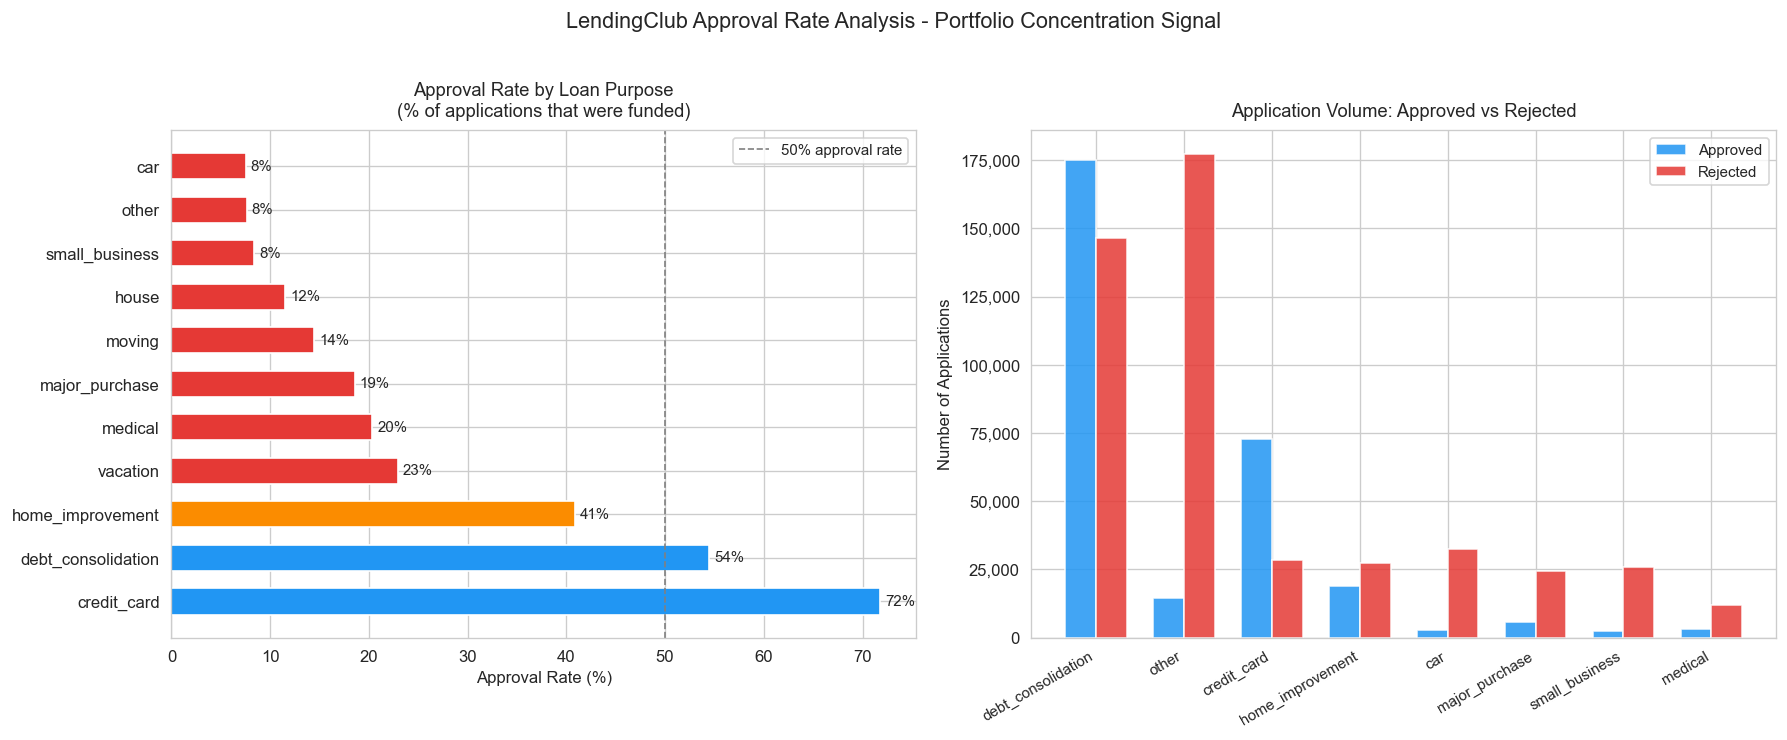

Purposes with approval rate below 40%:
  car                       rejection rate=92.5%  total_apps=34,953
  other                     rejection rate=92.4%  total_apps=191,750
  small_business            rejection rate=91.6%  total_apps=28,410
  house                     rejection rate=88.5%  total_apps=9,174
  moving                    rejection rate=85.5%  total_apps=13,229
  major_purchase            rejection rate=81.4%  total_apps=30,012
  medical                   rejection rate=79.7%  total_apps=15,018
  vacation                  rejection rate=77.1%  total_apps=7,927


In [6]:
print("APPROVAL RATE ANALYSIS - ACCEPTED vs REJECTED by PURPOSE")
print("="*75)

# rej_summary has: purpose_clean, rejected_count, approved_count, total_apps, rejection_rate
if len(rej_summary) > 0:
    rej_plot = rej_summary[rej_summary["total_apps"] > 1000].sort_values("rejection_rate",ascending=True).head(12)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Approval rate by purpose
    approval_rates = (1 - rej_plot["rejection_rate"]) * 100
    bar_colors_a = [RED if ar < 30 else "#FB8C00" if ar < 50 else BLUE
                    for ar in approval_rates.values]
    axes[0].barh(rej_plot["purpose_clean"], approval_rates.values,
                 color=bar_colors_a, edgecolor="white", height=0.6)
    axes[0].axvline(50, color="gray", ls="--", lw=1, label="50% approval rate")
    for i, (ar, pur) in enumerate(zip(approval_rates.values, rej_plot["purpose_clean"])):
        axes[0].text(ar+0.5, i, f"{ar:.0f}%", va="center", fontsize=9)
    axes[0].set_xlabel("Approval Rate (%)")
    axes[0].set_title("Approval Rate by Loan Purpose\n(% of applications that were funded)", fontsize=11, pad=8)
    axes[0].legend(fontsize=9)

    # Volume: approved vs rejected
    rej_vol = rej_summary[rej_summary["total_apps"] > 1000].nlargest(8, "total_apps")
    x = np.arange(len(rej_vol))
    w = 0.35
    axes[1].bar(x - w/2, rej_vol["approved_count"], w, label="Approved",
                color=BLUE, edgecolor="white", alpha=0.85)
    axes[1].bar(x + w/2, rej_vol["rejected_count"], w, label="Rejected",
                color=RED, edgecolor="white", alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(rej_vol["purpose_clean"], rotation=30, ha="right", fontsize=9)
    axes[1].set_ylabel("Number of Applications")
    axes[1].set_title("Application Volume: Approved vs Rejected", fontsize=11, pad=8)
    axes[1].legend(fontsize=9)
    axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{int(v):,}"))

    plt.suptitle("LendingClub Approval Rate Analysis - Portfolio Concentration Signal", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    print("Purposes with approval rate below 40%:")
    low_approval = rej_summary[rej_summary["rejection_rate"] > 0.60].sort_values("rejection_rate",ascending=False)
    for _, row in low_approval.iterrows():
        if row["total_apps"] > 500:
            print(f"  {row['purpose_clean']:<25} rejection rate={row['rejection_rate']*100:.1f}%  "
                  f"total_apps={int(row['total_apps']):,}")


---
## 6. Concentration Flag Logic — Decision Engine Integration

The concentration flag is a binary signal that the Decision Engine can use to trigger
Manual Review for loans that would add dangerous portfolio concentration.

It is not a hard decline (that's the PD model's job) but a **risk committee trigger**:
"This loan is individually acceptable but portfolio-level concentration warrants review."


CONCENTRATION FLAG LOGIC AND VALIDATION
Test set results:
  Loans flagged         : 15,059 (25.1%)
  Default rate (flagged): 0.3676 (36.8%)
  Default rate (clean)  : 0.1462 (14.6%)
  Lift from flag        : 2.51x



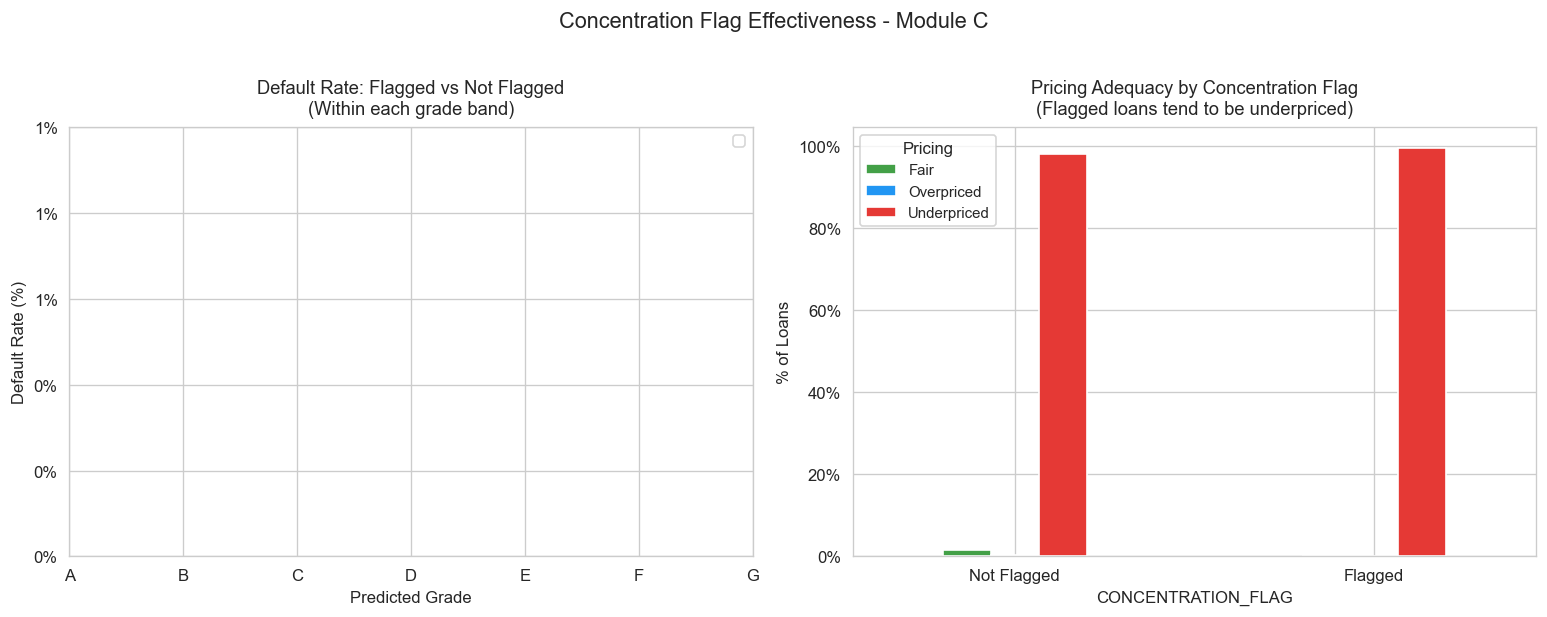

In [7]:
# Recompute flags on test set for validation
print("CONCENTRATION FLAG LOGIC AND VALIDATION")
print("="*65)

if "purpose" in df.columns:
    # Portfolio thresholds (based on observed composition)
    top_purpose     = df["purpose"].value_counts().index[0]
    top_purpose_pct = df["purpose"].value_counts(normalize=True).iloc[0]
    
    if "term_months" in df.columns:
        term_60_pct = (df["term_months"]==60).mean()
    else:
        term_60_pct = 0.3

    print(f"Current portfolio composition:")
    print(f"  Top purpose ({top_purpose}): {top_purpose_pct*100:.1f}%")
    print(f"  60-month term: {term_60_pct*100:.1f}%")
    print()
    print("Concentration flag triggers (any of the following):")
    print("  1. Loan purpose = small_business / house / renewable_energy (high default rate)")
    print("  2. 60-month term (2.5x default rate vs 36-month)")
    print()

if "CONCENTRATION_FLAG" in scored_c.columns:
    n_flagged  = scored_c["CONCENTRATION_FLAG"].sum()
    pct_flagged = n_flagged / len(scored_c) * 100
    dr_flagged  = scored_c.loc[scored_c["CONCENTRATION_FLAG"]==1, "ACTUAL_DEFAULT"].mean()
    dr_clean    = scored_c.loc[scored_c["CONCENTRATION_FLAG"]==0, "ACTUAL_DEFAULT"].mean()

    print(f"Test set results:")
    print(f"  Loans flagged         : {n_flagged:,} ({pct_flagged:.1f}%)")
    print(f"  Default rate (flagged): {dr_flagged:.4f} ({dr_flagged*100:.1f}%)")
    print(f"  Default rate (clean)  : {dr_clean:.4f} ({dr_clean*100:.1f}%)")
    print(f"  Lift from flag        : {dr_flagged/dr_clean:.2f}x")
    print()

# Visualise flag effectiveness
if "CONCENTRATION_FLAG" in scored_c.columns and "PREDICTED_GRADE" in scored_c.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Default rate: flagged vs non-flagged by grade
    grade_flag_dr = scored_c.groupby(["PREDICTED_GRADE","CONCENTRATION_FLAG"])["ACTUAL_DEFAULT"].mean().unstack()
    grade_flag_dr.columns = ["Not Flagged","Flagged"]
    grade_flag_dr = grade_flag_dr.reindex([g for g in "ABCDEFG" if g in grade_flag_dr.index])
    
    x_g = np.arange(len(grade_flag_dr))
    w   = 0.3
    if 0 in grade_flag_dr.columns:
        axes[0].bar(x_g-w/2, grade_flag_dr[0]*100, w, label="Not Flagged", color=BLUE, edgecolor="white")
    if 1 in grade_flag_dr.columns:
        axes[0].bar(x_g+w/2, grade_flag_dr[1]*100, w, label="Flagged", color=RED, edgecolor="white")
    axes[0].set_xticks(x_g)
    axes[0].set_xticklabels(grade_flag_dr.index)
    axes[0].set_xlabel("Predicted Grade"); axes[0].set_ylabel("Default Rate (%)")
    axes[0].set_title("Default Rate: Flagged vs Not Flagged\n(Within each grade band)", fontsize=11, pad=8)
    axes[0].legend(fontsize=9)
    axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v:.0f}%"))

    # Pricing adequacy by concentration flag
    if "PRICING_ADEQUACY" in scored_c.columns:
        flag_pricing = scored_c.groupby(["CONCENTRATION_FLAG","PRICING_ADEQUACY"]).size().unstack(fill_value=0)
        flag_pricing_pct = flag_pricing.div(flag_pricing.sum(axis=1), axis=0) * 100
        flag_pricing_pct.plot(kind="bar", ax=axes[1],
                               color={"Underpriced":RED,"Fair":"#43A047","Overpriced":BLUE},
                               edgecolor="white", width=0.4)
        axes[1].set_xticklabels(["Not Flagged","Flagged"], rotation=0)
        axes[1].set_ylabel("% of Loans")
        axes[1].set_title("Pricing Adequacy by Concentration Flag\n(Flagged loans tend to be underpriced)", fontsize=11, pad=8)
        axes[1].legend(title="Pricing", fontsize=9)
        axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v:.0f}%"))

    plt.suptitle("Concentration Flag Effectiveness - Module C", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


---
## 7. Save Portfolio Analysis Outputs

In [8]:
# Portfolio summary by grade
portfolio_summary = df.groupby("grade").agg(
    loan_count    = ("DEFAULT", "count"),
    default_rate  = ("DEFAULT", "mean"),
    avg_loan_amnt = ("loan_amnt", "mean") if "loan_amnt" in df.columns else ("DEFAULT","mean"),
).round(4)
portfolio_summary["portfolio_pct"] = (portfolio_summary["loan_count"] /
                                       portfolio_summary["loan_count"].sum() * 100).round(2)
portfolio_summary.to_csv("../04_outputs/portfolio_summary_c.csv")

# HHI summary
hhi_summary = pd.DataFrame([
    {"dimension": k, "hhi": compute_hhi(df[col])}
    for k, col in [("Grade","grade"),("Term","term_months"),
                   ("Purpose","purpose"),("Home Ownership","home_ownership")]
    if col in df.columns
])
hhi_summary.to_csv("../04_outputs/hhi_summary.csv", index=False)

print("Portfolio analysis outputs saved:")
print("  ../04_outputs/portfolio_summary_c.csv")
print("  ../04_outputs/hhi_summary.csv")
print()
print(portfolio_summary.to_string())


Portfolio analysis outputs saved:
  ../04_outputs/portfolio_summary_c.csv
  ../04_outputs/hhi_summary.csv

       loan_count  default_rate  avg_loan_amnt  portfolio_pct
grade                                                        
A           57714        0.0548     14581.1315          19.25
B           86689        0.1302     13528.0425          28.91
C           83335        0.2260     13927.9489          27.79
D           41564        0.3252     15212.4314          13.86
E           22617        0.4222     18107.5706           7.54
F            6531        0.5162     19891.8313           2.18
G            1427        0.5515     19991.0652           0.48


---
## 8. Module C — Complete Signal Output

### Full Signal Schema for Decision Engine

```
market_pd           : float  — Market-implied P(default) from grade prediction
loan_grade_signal   : str    — Predicted LendingClub-equivalent grade (A-G)
suggested_rate      : float  — Risk-appropriate interest rate (% p.a.)
pricing_adequacy    : str    — "Underpriced" / "Fair" / "Overpriced"
concentration_flag  : bool   — High-risk purpose or 60-month term
```

### Decision Engine Integration — Reprice Logic

```
If pricing_adequacy == "Underpriced" AND concentration_flag == False:
    Decision = "REPRICE"   (good borrower, just needs a higher rate)
    Suggested rate = module_c.suggested_rate

If pricing_adequacy == "Underpriced" AND concentration_flag == True:
    Decision = "MANUAL REVIEW"   (risky pricing + concentration concern)

If concentration_flag == True AND market_pd > 0.25:
    Decision = "MANUAL REVIEW"   (concentration + high market PD)
```

### Project Status After Module C

| Module | Dataset | Notebooks | Status |
|--------|---------|-----------|--------|
| A - Application Risk | Home Credit | 6 | Complete |
| B - Behavioural Risk | Give Me Some Credit | 4 | Complete |
| C - Portfolio/Pricing | LendingClub | 3 | Complete |
| D - Decision Engine | All signals | - | Next |
| Governance | Cross-module | - | Next |

Module A: 6 notebooks, Module B: 4 notebooks, Module C: 3 notebooks
Total: **13 notebooks** across 3 datasets, 3 risk dimensions.
